# SparseSensing Tutorial 04

This notebook demonstrates the `spatiotemporal` reshape mode. In this mode, each selected sensor is a `(space, time)` measurement pair instead of only a physical location.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pysensors as ps

alphas = np.linspace(0.1, 1.0, 5)
times = np.linspace(0.0, 1.0, 8)
x = np.linspace(0.0, 1.0, 20)
T = np.array([
    np.exp(-times[:, None]) * np.sin((3.0 + alpha) * np.pi * x)[None, :]
    for alpha in alphas
])
T.shape

(5, 8, 20)

The input tensor has shape `(n_samples, n_time, n_space) = (5, 8, 20)`. For `spatiotemporal`, rows stay as samples and columns encode `space * time`.

In [2]:
schedule_matrix = T.transpose(0, 2, 1).reshape(len(alphas), len(x) * len(times))
model = ps.SSPOR(
    basis=ps.basis.Identity(n_basis_modes=len(alphas)),
    n_sensors=6,
    optimizer=ps.optimizers.QR(),
)
model.fit(schedule_matrix, seed=42)
selected = np.sort(model.get_selected_sensors())
space_idx = selected // len(times)
time_idx = selected % len(times)
selected, space_idx, time_idx

(array([ 24,  57,  88, 112, 128, 152], dtype=int32),
 array([ 3,  7, 11, 14, 16, 19], dtype=int32),
 array([0, 1, 0, 0, 0, 0], dtype=int32))

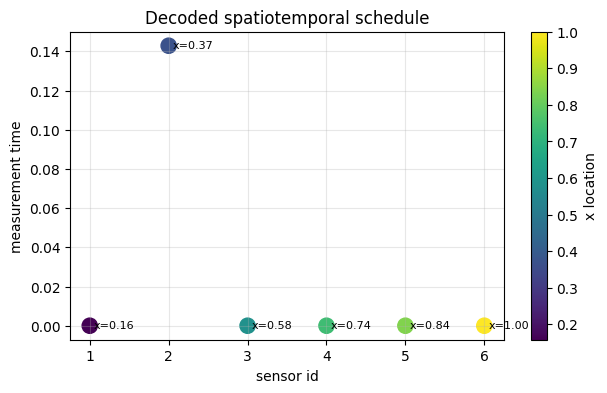

In [3]:
fig, ax = plt.subplots(figsize=(7, 4))
sc = ax.scatter(np.arange(1, len(selected) + 1), times[time_idx], c=x[space_idx], s=120, cmap='viridis')
for sid, sx, st in zip(np.arange(1, len(selected) + 1), x[space_idx], times[time_idx]):
    ax.text(sid + 0.05, st, f'x={sx:.2f}', fontsize=8, va='center')
ax.set_xlabel('sensor id')
ax.set_ylabel('measurement time')
ax.set_title('Decoded spatiotemporal schedule')
cbar = fig.colorbar(sc, ax=ax)
cbar.set_label('x location')
ax.grid(True, alpha=0.3)
plt.show()

Compared with tutorial 03, the output here is a **measurement schedule**: each chosen column is a specific `(x, time)` observation. This is useful when sensors can be moved or sampled selectively over time.